---
title: 'Solutions: Taking Derivatives with Automatic Differentiation'
author: Mark Fuge
format:
    html:
        code-fold: true
        code-summary: "Show Solution Code"
---

Worked solutions to the exercises at the end of the chapter *Taking Derivatives with Automatic Differentiation*. Each solution regenerates what it needs from the chapter.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def mccormick(x):
    return torch.sin(x[0]+x[1]) + (x[0]-x[1])**2 - 1.5*x[0]+2.5*x[1]+1

### Exercise 1: Forward mode through an unrolled solver

**(a)** At $(M, e) = (0, \tfrac{1}{2})$ every sine is zero. The forward pass gives $v_3 = v_4 = v_5 = v_6 = v_7 = v_8 = 0$, $f = 0$, $v_9 = 1$, $v_{10} = \tfrac{1}{2}$ and $r = \tfrac{1}{2}$. ($E = 0$ solves Kepler's equation for $M = 0$, so the iteration starts at the solution.) The tangent table for the seed $(\dot{M}, \dot{e}) = (1, 0)$ is

| Node | Tangent rule | Value |
|---|---|---|
| $\dot{v}_1$ | $\dot{M}$ | 1 |
| $\dot{v}_2$ | $\dot{e}$ | 0 |
| $\dot{v}_3$ | $\cos(v_1)\,\dot{v}_1$ | $1 \cdot 1 = 1$ |
| $\dot{v}_4$ | $\dot{v}_2 v_3 + v_2 \dot{v}_3$ | $0 + \tfrac{1}{2} \cdot 1 = 0.5$ |
| $\dot{v}_5$ | $\dot{v}_1 + \dot{v}_4$ | $1.5$ |
| $\dot{v}_6$ | $\cos(v_5)\,\dot{v}_5$ | $1.5$ |
| $\dot{v}_7$ | $\dot{v}_2 v_6 + v_2 \dot{v}_6$ | $0 + \tfrac{1}{2} \cdot 1.5 = 0.75$ |
| $\dot{v}_8$ | $\dot{v}_1 + \dot{v}_7$ | $1.75$ |
| $\dot{f}$ | $\dot{v}_8 - \dot{v}_1$ | $0.75$ |
| $\dot{v}_9$ | $-\sin(v_8)\,\dot{v}_8$ | $0$ |
| $\dot{v}_{10}$ | $\dot{v}_2 v_9 + v_2 \dot{v}_9$ | $0$ |
| $\dot{r}$ | $-\dot{v}_{10}$ | $0$ |

The pass gives $\partial f / \partial M = 0.75$ and $\partial r / \partial M = 0$: one forward pass gives the derivative of every output with respect to one input direction. $\partial r / \partial M$ is zero because $r$ depends on $M$ only through $\cos E_2$, and the derivative of the cosine, $-\sin E_2$, is zero at $E_2 = 0$.

**(b)** The seed $(0, 1)$ gives $\partial f / \partial e = 0$ and $\partial r / \partial e = -1$. The only nonzero tangent is $\dot{v}_{10} = \dot{v}_2 v_9 = 1$, because every sine in the graph is zero. The full $2 \times 2$ Jacobian needs two forward passes (one per input) or two `backward` calls (one per output). The counts are equal here because the function has as many inputs as outputs. In general forward mode costs one pass per input and reverse mode one pass per output (Exercise 2 (d)).

In [2]:
def kepler_two_iterations(M, e):
    """Two fixed-point iterations of Kepler's equation; returns (E_2 - M, 1 - e cos E_2)."""
    E = M
    for k in range(2):
        E = M + e*torch.sin(E)
    return E - M, 1 - e*torch.cos(E)


M = torch.tensor(0.0, requires_grad=True)
e = torch.tensor(0.5, requires_grad=True)
f_out, r_out = kepler_two_iterations(M, e)
f_out.backward(retain_graph=True)               # seed the output f
print(f"df/dM = {M.grad.item():.4f}, df/de = {e.grad.item():.4f}")
M.grad.zero_(); e.grad.zero_()                  # .grad accumulates, so clear it before the second output
r_out.backward()                                # seed the output r
print(f"dr/dM = {M.grad.item():.4f}, dr/de = {e.grad.item():.4f}")

df/dM = 0.7500, df/de = 0.0000
dr/dM = 0.0000, dr/de = -1.0000


**(c)** Each extra iteration adds the same three rows to the table (a sine, a product and a sum), so twenty iterations give a table of about sixty rows filled in with the same rules. The values change. The tangent of $E_k$ is $1, 1.5, 1.75, 1.875, \ldots$, because each iteration multiplies the previous tangent by $e \cos E_k = \tfrac{1}{2}$ and adds 1. It converges to $2 = 1/(1 - e \cos E)$, the derivative $dE/dM$ of the exact solution. The Verlet integrator at the end of the chapter is the same situation with 1000 steps: a long table filled in with local rules. Whether the tangent shrinks or grows along such a chain depends on the factor that each step multiplies it by, which is the subject of Exercise 4.

### Exercise 2: Reverse mode on a pump model

**(a)** The forward pass at $(Q, n, \rho) = (4, 4, 3)$ gives $v_4 = 16$, $v_5 = H = 4$, $v_6 = 2$, $v_7 = 12$, $P_h = 48$ and $\eta = 2$. The head $v_5$ is used by both outputs. $Q = v_1$ is used three times: in $v_5$, in $v_7$ and in $\eta$.

**(b)** The reverse pass seeded at $P_h$ ($\bar{P}_h = 1$, $\bar{\eta} = 0$):

| Node | Adjoint | Value |
|---|---|---|
| $\bar{v}_7$ | $\bar{P}_h \, v_5$ | 4 |
| $\bar{v}_5$ | $\bar{P}_h \, v_7$ | 12 |
| $\bar{v}_6$ | $\bar{\eta} \cdot (-v_1 / v_6^2)$ | 0 |
| $\bar{v}_4$ | $\bar{v}_5 / v_1$ | 3 |
| $\bar{v}_3$ | $\bar{v}_7 \, v_1$ | 16 |
| $\bar{v}_2$ | $\bar{v}_4 \cdot 2 v_2$ | 24 |
| $\bar{v}_1$ | $\bar{v}_7 v_3 \;+\; \bar{v}_5 (-v_4 / v_1^2) \;+\; \bar{\eta} / v_6$ | $12 - 12 + 0 = 0$ |

The reverse pass seeded at $\eta$ ($\bar{P}_h = 0$, $\bar{\eta} = 1$):

| Node | Adjoint | Value |
|---|---|---|
| $\bar{v}_7$ | $\bar{P}_h \, v_5$ | 0 |
| $\bar{v}_6$ | $\bar{\eta} \cdot (-v_1 / v_6^2)$ | $-1$ |
| $\bar{v}_5$ | $\bar{P}_h \, v_7 \;+\; \bar{v}_6 / (2\sqrt{v_5})$ | $0 - \tfrac{1}{4} = -\tfrac{1}{4}$ |
| $\bar{v}_4$ | $\bar{v}_5 / v_1$ | $-\tfrac{1}{16}$ |
| $\bar{v}_3$ | $\bar{v}_7 \, v_1$ | 0 |
| $\bar{v}_2$ | $\bar{v}_4 \cdot 2 v_2$ | $-\tfrac{1}{2}$ |
| $\bar{v}_1$ | $\bar{v}_7 v_3 \;+\; \bar{v}_5 (-v_4 / v_1^2) \;+\; \bar{\eta} / v_6$ | $0 + \tfrac{1}{4} + \tfrac{1}{2} = \tfrac{3}{4}$ |

$$
\frac{\partial (P_h, \eta)}{\partial (Q, n, \rho)} = \begin{pmatrix} 0 & 24 & 16 \\ \tfrac{3}{4} & -\tfrac{1}{2} & 0 \end{pmatrix}
$$

Adjoints are added wherever a node has more than one consumer. $\bar{v}_5$ receives contributions from $P_h$ and from $v_6$, and $\bar{v}_1$ receives three contributions because $Q$ is used three times. This is the chain rule for a function of several intermediate variables: the derivative of the output with respect to a node is the sum over all paths from that node to the output.

**(c)** In the $P_h$ pass, $Q$ receives $+12$ through $v_7 = \rho Q$ and $-12$ through $v_5 = n^2 / Q$, and they cancel exactly. Algebraically, $P_h = \rho\, Q \cdot n^2 / Q = \rho\, n^2$: in this toy model the hydraulic power does not depend on the flow rate at all, because the head law $H \propto 1/Q$ was chosen so that $Q H$ is constant. A real pump curve does not do that.

**(d)** For the pump, reverse mode needs two passes (one per output) and forward mode three (one per input). For the model that maps 2 design parameters to a 200-sample pressure trace, use forward mode: 2 passes give the full $200 \times 2$ Jacobian, where reverse mode would need 200. For the model that maps 200 blade coordinates to one efficiency, use reverse mode: 1 pass gives all 200 derivatives, where forward mode would need 200. Reverse mode costs memory. The backward pass needs the value of every intermediate node, so the whole forward computation must be stored (for a simulation, every time step). Forward mode carries the tangent along with the value and does not store the history.

**(e)** Both outputs share one graph. The first `backward` call needs `retain_graph=True` so that the graph still exists for the second call, and `.grad` must be zeroed between the calls. Otherwise the $\eta$ row is added to the $P_h$ row.

In [3]:
def pump(Q, n, rho):
    """Head, hydraulic power and efficiency of the simplified pump model."""
    H = n**2 / Q
    return rho * Q * H, Q / torch.sqrt(H)


Q = torch.tensor(4.0, requires_grad=True)
n = torch.tensor(4.0, requires_grad=True)
rho = torch.tensor(3.0, requires_grad=True)
P_h, eta = pump(Q, n, rho)
print(f"P_h = {P_h.item():.1f}, eta = {eta.item():.1f}")
P_h.backward(retain_graph=True)
jacobian_row_P = [Q.grad.item(), n.grad.item(), rho.grad.item()]
for p in (Q, n, rho):
    p.grad.zero_()
eta.backward()
jacobian_row_eta = [Q.grad.item(), n.grad.item(), rho.grad.item()]
print("d(P_h)/d(Q, n, rho) =", np.round(jacobian_row_P, 4))
print("d(eta)/d(Q, n, rho) =", np.round(jacobian_row_eta, 4))

P_h = 48.0, eta = 2.0
d(P_h)/d(Q, n, rho) = [ 0. 24. 16.]
d(eta)/d(Q, n, rho) = [ 0.75 -0.5   0.  ]


### Exercise 3: Reading the optimizer paths

In [4]:
def run_optimizer_path(start, make_optimizer, num_steps):
    """Run an optimizer on the McCormick function from `start` and return every iterate."""
    x = torch.tensor(start, requires_grad=True)
    optimizer = make_optimizer([x])
    path = [x.detach().numpy().copy()]
    for i in range(num_steps):
        def closure():
            optimizer.zero_grad()
            y = mccormick(x)
            y.backward()
            return y
        optimizer.step(closure)
        path.append(x.detach().numpy().copy())
    return np.array(path)


def gradient_norm(point):
    x = torch.tensor(point, requires_grad=True)
    mccormick(x).backward()
    return x.grad.norm().item()


x_opt = np.array([-0.54719, -1.54719])

# (a) The chapter's runs from (-4, 4)
chapter_adam = run_optimizer_path([-4.0, 4.0], lambda p: torch.optim.AdamW(p, lr=1), 50)
chapter_lbfgs = run_optimizer_path([-4.0, 4.0], lambda p: torch.optim.LBFGS(p, lr=0.05), 5)
step_lengths = np.linalg.norm(np.diff(chapter_adam, axis=0), axis=1)
print(f"AdamW first step: (-4, 4) -> ({chapter_adam[1][0]:.2f}, {chapter_adam[1][1]:.2f}); "
      f"step lengths 1 to 6: {np.round(step_lengths[:6], 2)}")
print(f"AdamW after 50 steps: distance to the minimum {np.linalg.norm(chapter_adam[-1] - x_opt):.3f}, "
      f"gradient norm {gradient_norm(chapter_adam[-1]):.2f}")
lbfgs_distances = np.linalg.norm(chapter_lbfgs - x_opt, axis=1)
print(f"L-BFGS distance to the minimum after each step call: {np.round(lbfgs_distances, 3)}")
print(f"ratio of successive distances: {np.round(lbfgs_distances[1:] / lbfgs_distances[:-1], 3)}; 0.95**20 = {0.95**20:.3f}")

# (b) Both optimizers from (3, 3)
second_start = [3.0, 3.0]
path_adam = run_optimizer_path(second_start, lambda p: torch.optim.AdamW(p, lr=1), 50)
path_lbfgs = run_optimizer_path(second_start, lambda p: torch.optim.LBFGS(p, lr=0.05), 5)
for name, path in [("AdamW", path_adam), ("L-BFGS", path_lbfgs)]:
    print(f"{name} from (3, 3): ends at ({path[-1][0]:.2f}, {path[-1][1]:.2f}), "
          f"f = {mccormick(torch.tensor(path[-1])).item():.2f}, gradient norm {gradient_norm(path[-1]):.3f}")
print(f"AdamW mean step length over its last 10 steps: {np.linalg.norm(np.diff(path_adam[-11:], axis=0), axis=1).mean():.2f}")

# (c) Along the valley floor x0 - x1 = 1 the function is sin(s) + s/2 with s = x0 + x1
s_min = 4*np.pi/3 - 2*np.pi*np.arange(3)          # valley minima, from (2.59, 1.59) downhill
for s in s_min:
    point = torch.tensor([(s + 1)/2, (s - 1)/2])
    print(f"valley at ({point[0]:.2f}, {point[1]:.2f}): f = {mccormick(point).item():.3f}")
ridge_height = (np.sin(2*np.pi/3) + np.pi/3) - (np.sin(4*np.pi/3) + 2*np.pi/3)
print(f"height of the ridge above the upper valley: {ridge_height:.2f}")

AdamW first step: (-4, 4) -> (-2.96, 2.96); step lengths 1 to 6: [1.47 1.43 1.37 1.27 1.13 0.93]
AdamW after 50 steps: distance to the minimum 0.054, gradient norm 0.17
L-BFGS distance to the minimum after each step call: [6.534 2.422 0.87  0.312 0.112 0.04 ]
ratio of successive distances: [0.371 0.359 0.359 0.359 0.359]; 0.95**20 = 0.358
AdamW from (3, 3): ends at (-11.59, -12.59), f = -11.27, gradient norm 1.526
L-BFGS from (3, 3): ends at (2.60, 1.60), f = 1.23, gradient norm 0.021
AdamW mean step length over its last 10 steps: 0.43
valley at (2.59, 1.59): f = 1.228
valley at (-0.55, -1.55): f = -1.913
valley at (-3.69, -4.69): f = -5.055
height of the ridge above the upper valley: 0.68


**(a)** *AdamW.* The gradient at $(-4, 4)$ is $(-16.5, 19.5)$. The first Adam step moves each coordinate by exactly `lr` $= 1$ against the sign of the gradient, whatever the size of the gradient, and weight decay pulls the point 4% toward zero, so the first step goes to $(-2.96, 2.96)$. The gradient keeps its sign for the next few steps, so the steps keep their direction and a length of about 1.4 (about 1 in each coordinate). The path crosses the valley floor and climbs the far side to about $(1.8, -2.5)$ before the gradient changes sign. The average $\hat{m}_t$ then needs several steps to turn around, and the steps get shorter as positive and negative gradients cancel in it. This produces the loop and the slow spiral toward the minimum. After 50 steps the iterate is still 0.05 from the minimum.

*L-BFGS.* Near the minimum the McCormick function is close to a quadratic, so the quasi-Newton direction points almost straight at the minimum. Each iteration moves 5% of the way, so the 20 iterations in one call of `step` leave $0.95^{20} = 0.36$ of the distance. The printed distances to the minimum shrink by exactly this factor from one call to the next. The five plotted points therefore lie on a nearly straight line, with gaps that shrink by the same factor.

**(b)** L-BFGS ends at $(2.60, 1.60)$ with $f = 1.23$ and a gradient norm of 0.02. This is the bottom of the valley it starts in, a local minimum. L-BFGS steps toward the minimum of a local quadratic model, so it converges to the nearest minimum and has no mechanism that would take it out.

AdamW ends at $(-11.6, -12.6)$ with $f = -11.3$, outside the chapter's plot window, and it is still moving: its last ten steps have an average length of 0.43. The valleys of the McCormick function lie along the line $x_0 - x_1 = 1$. Along that line each valley is $\pi \approx 3.14$ lower than the one before, and the ridge between two valleys is only 0.68 higher than the upper valley. Adam's steps do not get shorter just because the gradient is small, so AdamW passes through the valley at $(2.6, 1.6)$, crosses the ridge, and does the same in each following valley, passing close to the chapter's star on the way.

**(c)** Along the line $x_0 - x_1 = 1$ the McCormick function equals $\sin(s) + s/2$ with $s = x_0 + x_1$. This goes to $-\infty$ as $s \to -\infty$, so the function has no global minimum. The point $(-0.547, -1.547)$ is the minimum inside the box $x_0 \in [-1.5, 4]$, $x_1 \in [-3, 4]$ that benchmark tables use for this function. The chapter's plot window also contains the next valley, at $(-3.69, -4.69)$ with $f = -5.06$. The two runs fail in different ways: L-BFGS stops at a local minimum, and AdamW finds lower values by leaving the region where the stated optimum is defined. Before trusting where an optimizer stops, check that the gradient there is close to zero (true for L-BFGS, false for AdamW), that the point lies in the domain where the model is valid, and that runs from several starting points agree.

### Exercise 4: Vanishing and exploding gradients

In [5]:
def logistic_adjoints(r, x0=0.2, n_steps=40):
    """Run n_steps of the logistic map from x0; return the iterates x_k and the adjoints d x_N / d x_k."""
    xs = [torch.tensor(x0, dtype=torch.float64, requires_grad=True)]
    for k in range(n_steps):
        x_next = r * xs[-1] * (1 - xs[-1])
        x_next.retain_grad()
        xs.append(x_next)
    xs[-1].backward()
    return np.array([x.item() for x in xs]), np.array([x.grad.item() for x in xs])


# r = 2.5: fixed point and local derivative
iterates_stable, adjoints_stable = logistic_adjoints(2.5)
x_fixed = 1 - 1/2.5
print(f"r = 2.5: iterates x_0 to x_4 = {np.round(iterates_stable[:5], 4)}, fixed point 1 - 1/r = {x_fixed:.1f}, "
      f"local derivative r(1 - 2x*) = {2.5*(1 - 2*x_fixed):.2f}")
print(f"         dx_40/dx_0 = {adjoints_stable[0]:.3e}; 1.5 * 0.5 * 0.5**38 = {1.5*0.5*0.5**38:.3e}")

# r = 3.9: local derivatives along the run, and what the gradient means
iterates_chaotic, adjoints_chaotic = logistic_adjoints(3.9)
local_derivatives = 3.9*(1 - 2*iterates_chaotic[:-1])
growth_per_step = np.exp(np.mean(np.log(np.abs(local_derivatives))))
print(f"r = 3.9: {np.sum(np.abs(local_derivatives) > 1)} of 40 local derivatives have size above 1; "
      f"average growth per step {growth_per_step:.2f}; dx_40/dx_0 = {adjoints_chaotic[0]:.2e}")
x40_shifted = logistic_adjoints(3.9, x0=0.2 + 1e-10)[0][-1]
print(f"         x_40 from x_0 = 0.2: {iterates_chaotic[-1]:.3f}; from x_0 = 0.2 + 1e-10: {x40_shifted:.3f}")

r = 2.5: iterates x_0 to x_4 = [0.2 0.4 0.6 0.6 0.6], fixed point 1 - 1/r = 0.6, local derivative r(1 - 2x*) = -0.50
         dx_40/dx_0 = 2.728e-12; 1.5 * 0.5 * 0.5**38 = 2.728e-12
r = 3.9: 33 of 40 local derivatives have size above 1; average growth per step 1.76; dx_40/dx_0 = -6.37e+09
         x_40 from x_0 = 0.2: 0.891; from x_0 = 0.2 + 1e-10: 0.375


**(a)** Each step multiplies the adjoint by the local derivative $dx_{j+1}/dx_j = r(1 - 2x_j)$, so

$$
\bar{x}_k = \frac{\partial x_{40}}{\partial x_k} = \prod_{j=k}^{39} r\,(1 - 2x_j) .
$$

For $r = 2.5$ the fixed point solves $x = r x (1 - x)$, which gives $x^* = 1 - 1/r = 0.6$. The local derivative there is $r(1 - 2x^*) = 2 - r = -0.5$. From $x_0 = 0.2$ the iterates are 0.4 and then exactly 0.6, so from step 2 on every factor is $-0.5$. Going back one step halves the adjoint and flips its sign, as the printed values $1, -0.5, 0.25, -0.125$ show. A constant factor per step is a straight line on a logarithmic axis, here with a slope of $\log_{10} 0.5 \approx -0.3$ decades per step. The first two factors are 1.5 and 0.5, so $\partial x_{40} / \partial x_0 = 1.5 \cdot 0.5 \cdot 0.5^{38} \approx 2.7 \times 10^{-12}$.

**(b)** Every factor $r(1 - 2x_j)$ lies between $-r$ and $r$. For $r = 3.9$ the iterates never settle, and in this run 33 of the 40 factors have a size above 1. Their product grows by a factor of 1.76 per step on average, to $|\partial x_{40} / \partial x_0| \approx 6 \times 10^{9}$. The iterates stay in $[0, 1]$ because $x(1 - x) \le 1/4$, so $r\,x(1 - x) \le 0.975$. That bounds the values, not their derivatives. The gradient says that a change of $10^{-10}$ in $x_0$ changes $x_{40}$ by about 0.6, and it does: starting from $0.2 + 10^{-10}$ instead of $0.2$ gives $x_{40} = 0.375$ instead of $0.891$. A forward pass with reasonable values says nothing about whether its gradient is usable; the gradient has to be checked separately.

**(c)** Gradient descent changes $x_0$ by the learning rate times $\frac{\partial L}{\partial x_{40}}\, \bar{x}_0$. For $r = 2.5$ this is about $10^{-12}$ times what it would be for a one-step loop, so $x_0$ does not move. Here the small gradient is correct: every start in $(0, 1)$ ends at 0.6, so $x_{40}$ does not depend on $x_0$. A vanishing gradient becomes a problem when the loss does depend on an early input, because the gradient is then too small to show it. For $r = 3.9$ the gradient is about $10^{9}$ times larger, and any learning rate that is not tiny throws $x_0$ out of $[0, 1]$. A tiny learning rate does not help either: the loss as a function of $x_0$ changes completely over a distance of $10^{-10}$, so its local slope says nothing about where its minimum is. Each extra step multiplies the gradient by another factor of about 0.5 or 1.76, so both effects grow exponentially with the length of the loop.

A recurrent network has the same structure. The gradient of the loss with respect to an early input, or with respect to the weights at an early step, contains a product of one Jacobian per time step. Unless these Jacobians have a size close to one, the product shrinks or grows exponentially with the length of the sequence. This is why recurrent networks are trained with gradient clipping, or built from units such as the long short-term memory (LSTM) cell that are designed to keep the gradient from vanishing.

### Exercise 5: A heat exchanger formula with a hidden trap

In [6]:
def lmtd(dT1, dT2):
    """Log-mean temperature difference for end temperature differences dT1 and dT2."""
    return (dT1 - dT2) / torch.log(dT1 / dT2)


def lmtd_series_where(dT1, dT2, tol=1e-2):
    """Series near dT1 = dT2, formula elsewhere, selected with torch.where (NaN gradient at dT1 = dT2)."""
    u = (dT1 - dT2) / (dT1 + dT2)
    series = 0.5*(dT1 + dT2) * (1 - u**2/3 - 4*u**4/45)
    return torch.where(u.abs() < tol, series, lmtd(dT1, dT2))


def lmtd_stable(dT1, dT2, tol=1e-2):
    """Series near dT1 = dT2, formula elsewhere; the unused branch is evaluated at a harmless input."""
    u = (dT1 - dT2) / (dT1 + dT2)
    near = u.abs() < tol
    series = 0.5*(dT1 + dT2) * (1 - u**2/3 - 4*u**4/45)
    dT1_far = torch.where(near, 2*dT2, dT1)
    return torch.where(near, series, lmtd(dT1_far, dT2))


def value_and_slope(fun, delta, dtype=torch.float32):
    """fun and its autograd derivative with respect to dT1, at dT1 = 50 + delta and dT2 = 50."""
    dT1 = torch.tensor(50.0 + delta, dtype=dtype, requires_grad=True)
    dT2 = torch.tensor(50.0, dtype=dtype)
    value = fun(dT1, dT2)
    value.backward()
    return value.item(), dT1.grad.item()


print("float32, the chapter's formula against the series in float64 (accurate for small delta):")
for delta in [1.0, 1e-1, 1e-2, 1e-3, 1e-4]:
    v32, s32 = value_and_slope(lmtd, delta)
    v_ref, s_ref = value_and_slope(lmtd_stable, delta, torch.float64)
    print(f"  delta = {delta:6.0e} K: value {v32:8.4f} (reference {v_ref:8.4f}), derivative {s32:10.4g} (reference {s_ref:.4f})")
print("float64, the chapter's formula:")
for delta in [1e-5, 1e-6, 1e-7, 0.0]:
    v64, s64 = value_and_slope(lmtd, delta, torch.float64)
    print(f"  delta = {delta:6.0e} K: value {v64:.6f}, derivative {s64:.4g}")
print("float32 at delta = 0 and 1e-4:")
for name, fun in [("lmtd", lmtd), ("lmtd_series_where", lmtd_series_where), ("lmtd_stable", lmtd_stable)]:
    print(f"  {name:18s}: " + "; ".join(f"delta = {d:g}: value {v:.4f}, derivative {s:.4f}"
                                       for d in (0.0, 1e-4) for v, s in [value_and_slope(fun, d)]))

float32, the chapter's formula against the series in float64 (accurate for small delta):
  delta =  1e+00 K: value  50.4984 (reference  50.4983), derivative     0.4967 (reference 0.4967)
  delta =  1e-01 K: value  50.0499 (reference  50.0500), derivative     0.5009 (reference 0.4997)
  delta =  1e-02 K: value  50.0181 (reference  50.0050), derivative    -0.8125 (reference 0.5000)
  delta =  1e-03 K: value  49.9053 (reference  50.0005), derivative      95.61 (reference 0.5000)
  delta =  1e-04 K: value  48.9412 (reference  50.0000), derivative  1.045e+04 (reference 0.5000)
float64, the chapter's formula:
  delta =  1e-05 K: value 50.000005, derivative 0.5013
  delta =  1e-06 K: value 50.000001, derivative 0.3224
  delta =  1e-07 K: value 50.000002, derivative -19.48
  delta =  0e+00 K: value nan, derivative nan
float32 at delta = 0 and 1e-4:
  lmtd              : delta = 0: value nan, derivative nan; delta = 0.0001: value 48.9412, derivative 10449.9375
  lmtd_series_where : delta = 0: v

**(a)** It should approach $\tfrac{1}{2}$. Near $\Delta T_1 = \Delta T_2$ the log-mean temperature difference is the arithmetic mean $(\Delta T_1 + \Delta T_2)/2$ plus a correction of second order in $\Delta T_1 - \Delta T_2$ (derivation below), and the correction has zero slope at equality. Symmetry gives the same answer. $\Delta T_\mathrm{lm}$ does not change when $\Delta T_1$ and $\Delta T_2$ are swapped, and doubling both doubles it. So at $\Delta T_1 = \Delta T_2$ the two partial derivatives are equal and add up to 1.

::: {.callout-note collapse="true"}
### Derivation of the series for the log-mean temperature difference
Write $m = (\Delta T_1 + \Delta T_2)/2$ and $u = (\Delta T_1 - \Delta T_2)/(\Delta T_1 + \Delta T_2)$, so that $\Delta T_1 = m(1 + u)$ and $\Delta T_2 = m(1 - u)$. Then $\Delta T_1 - \Delta T_2 = 2mu$ and

$$
\ln\frac{\Delta T_1}{\Delta T_2} = \ln(1 + u) - \ln(1 - u) = 2\left(u + \frac{u^3}{3} + \frac{u^5}{5} + \ldots\right),
$$

so

$$
\Delta T_\mathrm{lm} = \frac{m}{1 + u^2/3 + u^4/5 + \ldots} = m\left(1 - \frac{u^2}{3} - \frac{4u^4}{45} + O(u^6)\right).
$$

At $u = 0$ the value is $m$. The derivative of $m$ with respect to $\Delta T_1$ is $\tfrac{1}{2}$, and the $u^2$ and $u^4$ terms have zero derivative at $u = 0$, so $\partial \Delta T_\mathrm{lm} / \partial \Delta T_1 = \tfrac{1}{2}$ there.
:::

**(b)** In `float32` the value is within 0.2% of the reference down to $\delta = 10^{-3}$ K and within about 2% at $10^{-4}$ K. The derivative is correct to about two digits down to $\delta = 0.1$ K. At $\delta = 10^{-2}$ K it is $-0.81$ instead of $0.50$, and at $10^{-4}$ K it is about $10^4$. At $\delta = 0$ both the value and the derivative are NaN.

The cause is rounding in `dT1 / dT2`. In `float32` the quotient is rounded to a relative accuracy of about $6 \times 10^{-8}$, so its logarithm has an absolute error of about $6 \times 10^{-8}$. The logarithm itself is only about $\delta / 50$. At $\delta = 10^{-3}$ K it is $2 \times 10^{-5}$, so the rounding is a relative error of about $3 \times 10^{-3}$ in the denominator, and the value is off by about that fraction. The derivative that autograd computes is

$$
\frac{\partial \Delta T_\mathrm{lm}}{\partial \Delta T_1} = \frac{1}{\ln(\Delta T_1/\Delta T_2)} - \frac{\Delta T_1 - \Delta T_2}{\Delta T_1 \ln^2(\Delta T_1/\Delta T_2)} .
$$

The two terms come from the division and the logarithm in the graph. Each has a size of about $50/\delta = 5 \times 10^4$, and they cancel down to $0.5$. A relative error of $3 \times 10^{-3}$ in terms of size $5 \times 10^4$ is an absolute error of about 150, far larger than the 0.5 that is left after the cancellation. The value contains no such cancellation, so it loses far fewer digits. At $\delta = 0$ the formula evaluates $0/0$, which is NaN, and the backward pass multiplies NaN into every derivative that depends on it.

**(c)** The optimizer would receive derivatives that are wrong by orders of magnitude and of random sign as it approaches balanced flow, and NaN if it reaches it. A NaN in one term of a loss makes the whole gradient NaN, so a single balanced exchanger in a larger plant model stops the optimization. Switching to `float64` only moves the problem closer to $\delta = 0$: the derivative is off by 0.3% at $\delta = 10^{-5}$ K and by a third at $10^{-6}$ K, and it is still NaN at $\delta = 0$.

The fix is to use the series near equality and the formula elsewhere. The series has no cancellation and no division by zero, and with the switch at $|u| < 10^{-2}$ its truncation error is about $u^6 \approx 10^{-12}$. There is a second trap in the implementation. `lmtd_series_where` above selects the branch with `torch.where` and returns the right value at $\delta = 0$, but its derivative is still NaN. Autograd differentiates both branches of `torch.where` and multiplies the unused one by zero, and $0 \times \mathrm{NaN} = \mathrm{NaN}$. `lmtd_stable` avoids this by evaluating the formula at a harmless input ($\Delta T_1 = 2 \Delta T_2$) wherever the series is used, and it gives $0.5$ at $\delta = 0$.

### Exercise 6: Fit damping and stiffness together

In [7]:
# The measured record from the chapter (same generator, same seed)
N_record = 200
t_record = np.linspace(0, 10, N_record)
dt_record = t_record[1] - t_record[0]


def _simulate_record(gamma_true, k_true):
    x0, v0 = 1.0, 1.0
    fac1 = 1.0 - 0.5*gamma_true*dt_record
    fac2 = 1.0/(1.0 + 0.5*gamma_true*dt_record)
    x = np.zeros(N_record)
    x[0] = x0
    for i in range(N_record - 1):
        v0 = fac1*fac2*v0 - fac2*dt_record*k_true*x0
        x0 = x0 + dt_record*v0
        x[i + 1] = x0
    return x


_record_rng = np.random.default_rng(0)
x_measured = _simulate_record(0.3, 2.0) + 0.05*_record_rng.normal(size=N_record)
x_measured_tensor = torch.tensor(x_measured, dtype=torch.float32)


def integrate_k(n_steps, x0, v0, gamma_p, k_p, dt_p):
    """Verlet integration of x'' + gamma x' + k x = 0; returns all positions as one tensor."""
    fac1 = 1.0 - 0.5*gamma_p*dt_p
    fac2 = 1.0/(1.0 + 0.5*gamma_p*dt_p)
    positions = [x0]
    for i in range(n_steps - 1):
        v0 = fac1*fac2*v0 - fac2*dt_p*k_p*x0
        x0 = x0 + dt_p*v0
        positions.append(x0)
    return torch.stack(positions)


def record_loss(params):
    x_simulated = integrate_k(N_record, torch.tensor(1.0), torch.tensor(1.0), params[0], params[1], dt_record)
    return torch.mean((x_simulated - x_measured_tensor)**2)


# Adam, recording (gamma, k) after every step
params_adam = torch.tensor([0.1, 1.0], requires_grad=True)
optimizer = torch.optim.Adam([params_adam], lr=0.05)
fit_path_adam = [params_adam.detach().numpy().copy()]
for step in range(60):
    optimizer.zero_grad()
    loss_adam = record_loss(params_adam)
    loss_adam.backward()
    optimizer.step()
    fit_path_adam.append(params_adam.detach().numpy().copy())
fit_path_adam = np.array(fit_path_adam)
print(f"Adam (60 steps):   gamma = {params_adam[0].item():.4f}, k = {params_adam[1].item():.4f}, loss = {loss_adam.item():.5f}")

# L-BFGS, recording (gamma, k) at every loss evaluation, i.e. every inner iteration
params_lbfgs = torch.tensor([0.1, 1.0], requires_grad=True)
optimizer = torch.optim.LBFGS([params_lbfgs], lr=0.5, max_iter=10)
fit_path_lbfgs = []
for step in range(5):
    def closure():
        optimizer.zero_grad()
        loss = record_loss(params_lbfgs)
        loss.backward()
        fit_path_lbfgs.append(params_lbfgs.detach().numpy().copy())
        return loss
    loss_lbfgs = optimizer.step(closure)
fit_path_lbfgs.append(params_lbfgs.detach().numpy().copy())
fit_path_lbfgs = np.array(fit_path_lbfgs)
print(f"L-BFGS (5 calls of step, {len(fit_path_lbfgs) - 1} loss evaluations): gamma = {params_lbfgs[0].item():.4f}, "
      f"k = {params_lbfgs[1].item():.4f}, loss = {loss_lbfgs.item():.5f}")
print(f"noise variance of the record: {0.05**2:.5f}")


def loss_np(gamma_value, k_value):
    return np.mean((_simulate_record(gamma_value, k_value) - x_measured)**2)


def gradient_np(gamma_value, k_value, h=1e-4):
    return np.array([(loss_np(gamma_value + h, k_value) - loss_np(gamma_value - h, k_value)) / (2*h),
                     (loss_np(gamma_value, k_value + h) - loss_np(gamma_value, k_value - h)) / (2*h)])


steps_gamma = np.abs(np.diff(fit_path_adam[:, 0]))
print(f"Adam: highest gamma {fit_path_adam[:, 0].max():.2f} at step {fit_path_adam[:, 0].argmax()}; "
      f"|change in gamma| per step: first 3 {np.round(steps_gamma[:3], 3)}, mean of the last 20 {steps_gamma[-20:].mean():.4f}")
print(f"gradient norm at the start {np.linalg.norm(gradient_np(0.1, 1.0)):.2f}, at Adam's end point {np.linalg.norm(gradient_np(*fit_path_adam[-1])):.3f}")
print(f"loss at the start (0.1, 1.0): {loss_np(0.1, 1.0):.2f}; loss of predicting x = 0 everywhere: {np.mean(x_measured**2):.2f}")
gamma_line = np.linspace(0, 1.5, 151)
for k_value in (1.0, 1.5, 2.0):
    print(f"best gamma for k = {k_value}: {gamma_line[np.argmin([loss_np(g, k_value) for g in gamma_line])]:.2f}")

Adam (60 steps):   gamma = 0.4057, k = 2.0936, loss = 0.01125
L-BFGS (5 calls of step, 25 loss evaluations): gamma = 0.3033, k = 1.9999, loss = 0.00230
noise variance of the record: 0.00250
Adam: highest gamma 0.66 at step 24; |change in gamma| per step: first 3 [0.05  0.049 0.048], mean of the last 20 0.0087
gradient norm at the start 2.87, at Adam's end point 0.096
loss at the start (0.1, 1.0): 0.81; loss of predicting x = 0 everywhere: 0.28
best gamma for k = 1.0: 1.07
best gamma for k = 1.5: 0.50
best gamma for k = 2.0: 0.30


grid minimum at gamma = 0.300, k = 2.000, loss = 0.00231


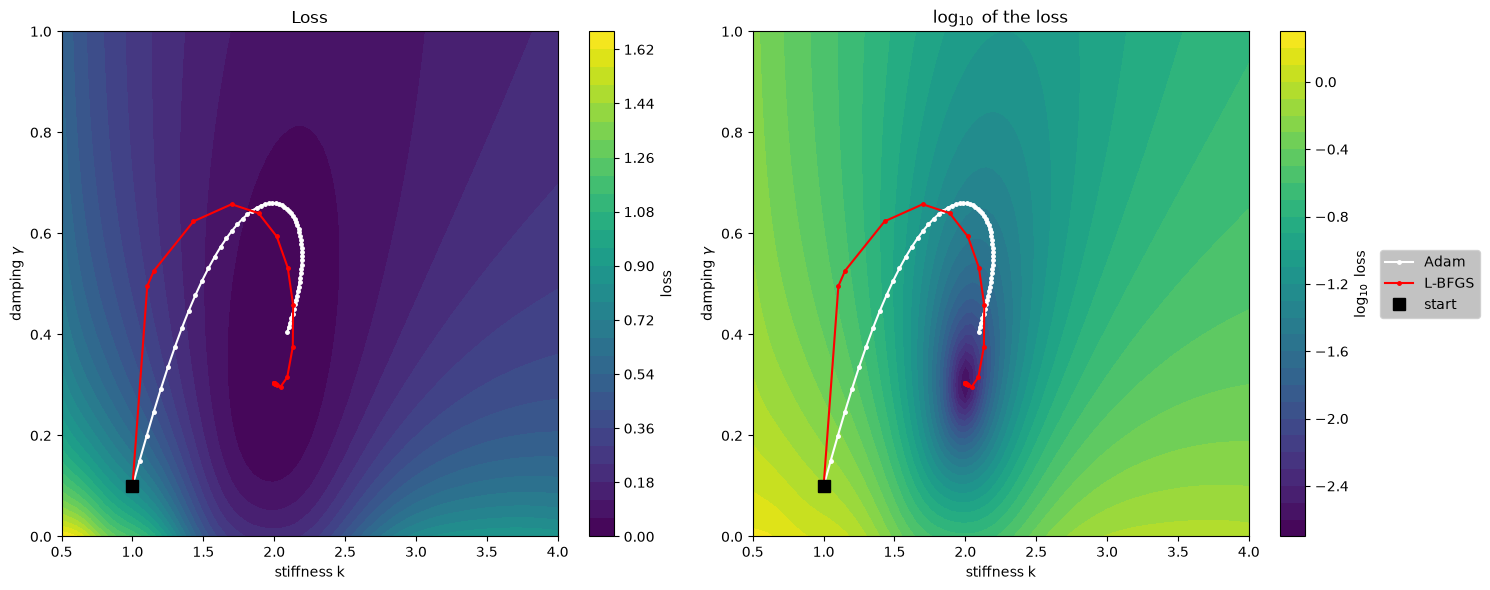

In [8]:
# The loss over a grid of (gamma, k) pairs (NumPy, for speed), with both optimizer paths
gamma_grid = np.linspace(0.0, 1.0, 41)
k_grid = np.linspace(0.5, 4.0, 71)
loss_grid = np.array([[loss_np(g, k) for k in k_grid] for g in gamma_grid])
i_best, j_best = np.unravel_index(np.argmin(loss_grid), loss_grid.shape)
print(f"grid minimum at gamma = {gamma_grid[i_best]:.3f}, k = {k_grid[j_best]:.3f}, loss = {loss_grid.min():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, surface, label in [(axes[0], loss_grid, "loss"), (axes[1], np.log10(loss_grid), r"$\log_{10}$ loss")]:
    filled = ax.contourf(k_grid, gamma_grid, surface, levels=30)
    fig.colorbar(filled, ax=ax, label=label)
    ax.plot(fit_path_adam[:, 1], fit_path_adam[:, 0], 'w.-', ms=5, label='Adam')
    ax.plot(fit_path_lbfgs[:, 1], fit_path_lbfgs[:, 0], 'r.-', ms=5, label='L-BFGS')
    ax.plot(1.0, 0.1, 'ks', ms=8, label='start')
    ax.set_xlabel('stiffness k')
    ax.set_ylabel(r'damping $\gamma$')
axes[0].set_title('Loss')
axes[1].set_title(r'$\log_{10}$ of the loss')
axes[1].legend(loc='center left', bbox_to_anchor=(1.25, 0.5), facecolor='0.7')
plt.tight_layout()
plt.show()

**(a)** `integrate_k` above is the chapter's Verlet loop with the restoring force $-k\,x$. It collects the positions in a list and stacks them into one tensor, so autograd can follow every position into the loss.

**(b)** The record was generated with $\gamma = 0.3$, $k = 2$ and noise with a standard deviation of 0.05, so a perfect fit has a loss of about $0.05^2 = 0.0025$. L-BFGS reaches $\gamma = 0.303$, $k = 2.000$ and a loss of 0.0023 in 5 calls of `step` (25 loss evaluations). After 60 steps Adam is at $\gamma = 0.41$, $k = 2.09$ with a loss of 0.011, and it is still moving.

The figure shows both paths. Both optimizers first raise $\gamma$ to about 0.65 while $k$ increases from 1 to 2, and then lower $\gamma$ along the bottom of the valley near $k = 2$ (part (c) explains the detour). Adam's first steps change each parameter by exactly `lr` $= 0.05$, as the chapter's description of Adam predicts. Near the minimum the loss is flat. The left map shows a wide region with a loss below 0.05, compared with 0.81 at the start. At Adam's end point the gradient norm is about 0.1, against 2.9 at the start, and $\hat{v}_t$ still contains the large early gradients, so Adam's steps in $\gamma$ have shrunk to under 0.01 per step over the last 20 steps. L-BFGS estimates the curvature from the change in gradient between iterations. In a flat region the curvature is small, so the quasi-Newton step is long, and L-BFGS crosses the region in a few iterations.

The logarithmic map makes the minimum look like a steep, well-defined bowl, because the logarithm stretches the small differences near the minimum. The linear map shows the flat region that the optimizers have to cross.

**(c)** The stiffness sets the frequency of the oscillation, $\omega = \sqrt{k - \gamma^2/4}$, so it is determined by the timing of the zero crossings. The damping sets how fast the amplitude decays, so it is determined by the ratio of successive peaks. The two interact in the fit because a wrong frequency can be partly compensated by more damping. With $k = 1$ the simulated oscillation is slower than the record and drifts out of phase with it, and an oscillation out of phase with the record has a larger squared error than no oscillation at all: the loss at the start, $(\gamma, k) = (0.1, 1)$, is 0.81, while predicting $x = 0$ everywhere gives 0.28. The best damping for $k = 1$ is therefore large, about 1.07, which damps the wrong oscillation out quickly. For $k = 1.5$ the best damping is 0.5, and for $k = 2$ it is 0.3. This is why both optimizers first raise $\gamma$: while $k$ is wrong, more damping lowers the loss. Once $k$ is close to 2, the best $\gamma$ drops to 0.3 and they come back down. With $k$ known, as in the chapter, the frequency is right from the start, the compensation never happens, and the loss is a curve in $\gamma$ alone with a single minimum.